Read header and print it

In [1]:
from ptuio.reader import TTTRReader

reader = TTTRReader(r"C:\Users\dalibor\Data\Yaiza\2025-11-25_NADH_FLIM.sptw\MCF7_Tam5R.sptw\MCF7 Tam5R_12.ptu")
for key, value in reader.header.tags.items():
    print(f'{key}: {value}')

Measurement_SubMode = reader.header.tags.get("Measurement_SubMode")

if Measurement_SubMode<1:
    print("Not an image. You must set scanning configuration.")
else:
    ImgHdr_PixX = reader.header.tags.get("ImgHdr_PixX")
    ImgHdr_PixY = reader.header.tags.get("ImgHdr_PixY")

# This file is recorded in point mode - scanner information is not in the header, but the markers are recorded anyway

File_GUID: {98D39CE6-8363-4F13-989F-C307DCF26A3A}
File_CreatingTime: 2025-11-25 11:49:59.555000
Measurement_SubMode: 0
File_Comment: 512x512px, zoom 2.0, speed 5, accu 16, 1 frame , ex 740 nm, pwr 6%, OPO in, 10% = 16 mW 
TTResult_StopReason: 1
Fast_Load_End: <Empty>
CreatorSW_Name: SymPhoTime 64
CreatorSW_Version: 2.7
CreatorSW_SVNBuild: 5615
CreatorSW_Modules: 0
ImgHdr_Dimensions: 1
ImgHdr_Ident: 3
Measurement_Mode: 3
HW_Type: HydraHarp
HW_SerialNo: 1027371
HW_Version: 2.0
HW_ExternalRefClock: False
HW_Modules: 4
HWModule_TypeCode[0]: 1000
HWModule_VersCode[0]: 51052545
HWModule_TypeCode[1]: 1010
HWModule_VersCode[1]: 33554954
HWModule_TypeCode[2]: 1040
HWModule_VersCode[2]: 18153994
HWModule_TypeCode[3]: 1040
HWModule_VersCode[3]: 18153994
HW_Markers: 4
HWMarkers_Enabled[0]: True
HWMarkers_RisingEdge[0]: False
HWMarkers_Enabled[1]: True
HWMarkers_RisingEdge[1]: True
HWMarkers_Enabled[2]: True
HWMarkers_RisingEdge[2]: False
HWMarkers_Enabled[3]: True
HWMarkers_RisingEdge[3]: False
HW

Get some useful constants from the header

In [2]:
from ptuio.utils import estimate_tcspc_bins
import numpy as np

wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=0) # if buffer = 0, channel overflow can be expected


Read all markers that are saved in .ptu file

In [3]:
from ptuio.utils import get_marker_distribution, marker_events
from ptuio.decoder import T3OverflowCorrector


corrector = T3OverflowCorrector(wraparound=wrap)

all_markers = []

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    all_markers.append(marker_events(corrected_chunk))

all_markers = np.concatenate(all_markers)
print(get_marker_distribution(all_markers))
    
# Marker channel 1 -> line start
# Marker channel 2 -> line stop 
# Marker channel 4 -> frame start
# Any other channel would mean there is something wrong

# From the total number of markers one can guess the shape of the image. Here 3 * 16 * 1024 = 49152, i.e., 3 frames, 16 accumulations, 1024 pixels


{1: 8192, 2: 8192, 4: 1, 58: 1}


Reconstruct only photon count (i.e., intensity) image

In [4]:
from ptuio.reconstructor import ScanConfig
from ptuio.reconstructor import ImageReconstructor

cfg = ScanConfig(
    bidirectional=True, 
    bidirectional_phase_shift=0.013,
    frames= 1,
    lines=512, 
    pixels=512, 
    line_accumulations= (16,),
    max_detector=2
    )

reconstructor = ImageReconstructor(
        config=cfg, 
        tcspc_channels= tcspc_bins,
        outputs=['photon_count']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
image = result.photon_count


Reconstruction finished.


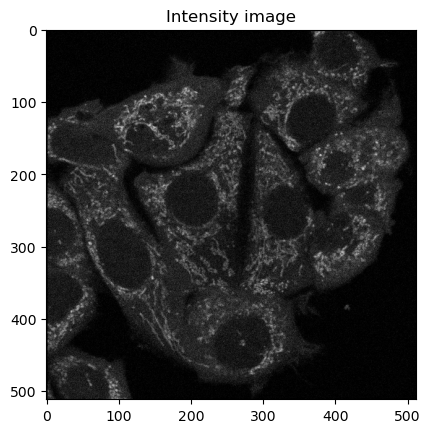

In [5]:
import matplotlib.pyplot as plt
image_slice = image.isel(frame=0,sequence=0,channel=0)

fig, ax = plt.subplots()
ax.imshow(image_slice,cmap='gray')
ax.set_title('Intensity image')
plt.show()

# bi-directional scan phase shift needs adjusting


Estimate bi-directional scan phase shift

Estimating bidirectional phase shift...
Shift 0.0030 → score 1802575.88
Shift 0.0050 → score 1841382.00
Shift 0.0070 → score 1904704.75
Shift 0.0090 → score 2000132.62
Shift 0.0110 → score 2121962.50
Shift 0.0130 → score 2202299.75
Shift 0.0150 → score 2180727.50
Shift 0.0170 → score 2074007.00
Shift 0.0190 → score 1961582.88
Shift 0.0210 → score 1883672.62
Shift 0.0230 → score 1831539.75
Best estimated shift: 0.01364


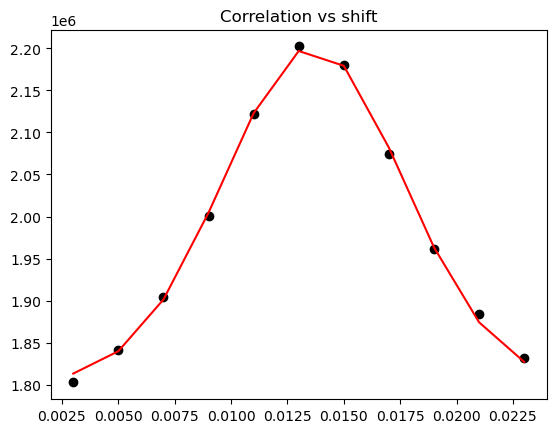

In [6]:
from ptuio.utils import estimate_bidirectional_shift

estimated_phase = estimate_bidirectional_shift(
        reader=reader,
        config=cfg
        )

optimized_phase_shift, scores = estimated_phase
_, ax = plt.subplots()
ax.plot(scores[0],scores[1],color='black',marker='o',linestyle='')
ax.plot(scores[0],scores[2],color='red',linestyle='-')
ax.set_title('Correlation vs shift')
plt.show()


Reconstruct FLIM image with extimated optimized shift

In [7]:
cfg.bidirectional_phase_shift = optimized_phase_shift

# For FLIM image you need both intensity and lifetime image -> specify those in outputs parameter
reconstructor = ImageReconstructor(
        config=cfg, 
        tcspc_channels= tcspc_bins + 5, # add some buffer manually
        outputs=['photon_count','mean_arrival_time']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()


Reconstruction finished.


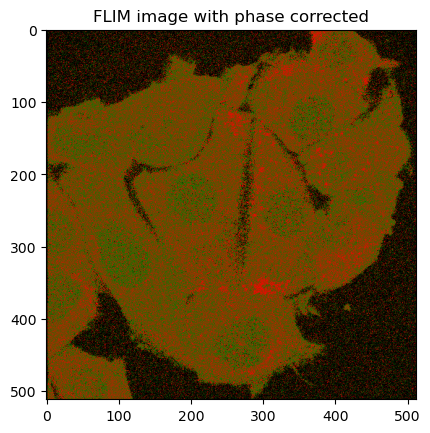

In [8]:
from ptuio.utils import create_FLIM_image
import matplotlib.colors as mcolors
colormap = mcolors.LinearSegmentedColormap.from_list("green_red", ["green", "red"])

FLIM_image = create_FLIM_image(mean_photon_arrival_time=result.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values * tcspc_resolution * 1e9, 
                               intensity=result.photon_count.isel(frame=0,sequence=0,channel=0).values, 
                               lt_min=1, 
                               lt_max = 5,
                               int_min=0,
                               int_max=5,
                               colormap=colormap)

fig, ax = plt.subplots()
ax.imshow(FLIM_image)
ax.set_title('FLIM image with phase corrected')
plt.show()


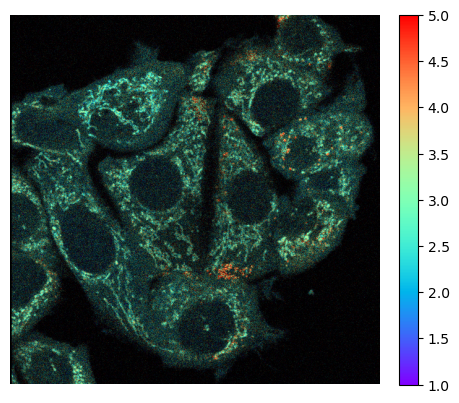

In [16]:
from ptuio.utils import create_FLIM_image
import matplotlib.colors as mcolors
from matplotlib import cm

# colormap = mcolors.LinearSegmentedColormap.from_list("green_red", ["green", "red"])

colormap = cm.rainbow

FLIM_image = create_FLIM_image(mean_photon_arrival_time=result.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values * tcspc_resolution * 1e9, 
                               intensity=result.photon_count.isel(frame=0,sequence=0,channel=0).values, 
                               lt_min=1, 
                               lt_max = 5,
                               int_min=0,
                               int_max=50,
                               colormap=colormap)

fig, ax = plt.subplots()
ax.set_axis_off()
img = ax.imshow(FLIM_image, cmap=colormap,vmin=1,vmax = 5)
# ax.set_title('FLIM image with phase corrected')
fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
plt.show()


In [ ]:
FLIM_image_conv = create_FLIM_image(mean_photon_arrival_time_conv.values, total_photon_count_conv.values,lt_min=lt_min, lt_max = lt_max)  # Apply intensity

fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=False)
img1 = ax[0].imshow(FLIM_image_conv, cmap=cm.rainbow, vmin=lt_min, vmax=lt_max)
ax[0].axis("off")
fig.colorbar(img1, ax=ax[0], fraction=0.046, pad=0.04)


img2 = ax[1].imshow(total_photon_count_conv / kernel.sum(), cmap='gray', vmin=0, vmax=total_photon_count_conv.max() / kernel.sum())
ax[1].axis("off")
fig.colorbar(img2, ax=ax[1], fraction=0.046, pad=0.04)